# 10.5 多头注意力
:label:`sec_multihead-attention`

在实践中，当给定相同的查询、键和值的集合时，
我们希望模型可以基于相同的注意力机制学习到不同的行为，
然后将不同的行为作为知识组合起来，
捕获序列内各种范围的依赖关系
（例如，短距离依赖和长距离依赖关系）。
因此，允许注意力机制组合使用查询、键和值的不同
*子空间表示*（representation subspaces）可能是有益的。

为此，与其只使用单独一个注意力汇聚，
我们可以用独立学习得到的$h$组不同的
*线性投影*（linear projections）来变换查询、键和值。
然后，这$h$组变换后的查询、键和值将并行地送到注意力汇聚中。
最后，将这$h$个注意力汇聚的输出拼接在一起，
并且通过另一个可以学习的线性投影进行变换，
以产生最终输出。
这种设计被称为*多头注意力*（multihead attention）
 :cite:`Vaswani.Shazeer.Parmar.ea.2017`。
对于$h$个注意力汇聚输出，每一个注意力汇聚都被称作一个*头*（head）。
 :numref:`fig_multi-head-attention`
展示了使用全连接层来实现可学习的线性变换的多头注意力。

![多头注意力：多个头连结然后线性变换](../img/multi-head-attention.svg)
:label:`fig_multi-head-attention`

## 10.5.1 模型

在实现多头注意力之前，让我们用数学语言将这个模型形式化地描述出来。
给定查询$\mathbf{q} \in \mathbb{R}^{d_q}$、
键$\mathbf{k} \in \mathbb{R}^{d_k}$和
值$\mathbf{v} \in \mathbb{R}^{d_v}$，
每个注意力头$\mathbf{h}_i$（$i = 1, \ldots, h$）的计算方法为：

$$\mathbf{h}_i = f(\mathbf W_i^{(q)}\mathbf q, \mathbf W_i^{(k)}\mathbf k,\mathbf W_i^{(v)}\mathbf v) \in \mathbb R^{p_v},$$

其中，可学习的参数包括
$\mathbf W_i^{(q)}\in\mathbb R^{p_q\times d_q}$、
$\mathbf W_i^{(k)}\in\mathbb R^{p_k\times d_k}$和
$\mathbf W_i^{(v)}\in\mathbb R^{p_v\times d_v}$，
以及代表注意力汇聚的函数$f$。
$f$可以是 :numref:`sec_attention-scoring-functions`中的
加性注意力和缩放点积注意力。
多头注意力的输出需要经过另一个线性转换，
它对应着$h$个头连结后的结果，因此其可学习参数是
$\mathbf W_o\in\mathbb R^{p_o\times h p_v}$：

$$\mathbf W_o \begin{bmatrix}\mathbf h_1\\\vdots\\\mathbf h_h\end{bmatrix} \in \mathbb{R}^{p_o}.$$

基于这种设计，每个头都可能会关注输入的不同部分，
可以表示比简单加权平均值更复杂的函数。

In [2]:
import math
import torch
from torch import nn
from d2l import torch as d2l

## 10.5.2 实现

在实现过程中通常**选择缩放点积注意力作为每一个注意力头**。
为了避免计算代价和参数代价的大幅增长，
我们设定$p_q = p_k = p_v = p_o / h$。
值得注意的是，如果将查询、键和值的线性变换的输出数量设置为
$p_q h = p_k h = p_v h = p_o$，
则可以并行计算$h$个头。
在下面的实现中，$p_o$是通过参数`num_hiddens`指定的。

<span style="color:#6B8CBE;font-weight:600;font-size:16px">&ensp;就是说如果想产生 h 个头(有 h 个 $W_q$, 每个 $W_q$ 形状为(query_size, hidden), W_k, W_v 同理 ), 那么可以并行地, 一次性产生 $ h*q $ 个, 即 $W_q$ 形状为(query_size, hidden*num_head), 然后 `reshape`, 变为(query_size, num_head, hidden).<br>
&ensp;我们令 $ num\_hidden = hidden * num\_head $.<br>
</span>

In [3]:
#@save
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # queries，keys，values的形状:
        # (batch_size，查询或者“键－值”对的个数，num_hiddens)
        # valid_lens　的形状:
        # (batch_size，)或(batch_size，查询的个数)
        # 经过变换后，输出的queries，keys，values　的形状:
        # (batch_size*num_heads，查询或者“键－值”对的个数，
        # num_hiddens/num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # 在轴0，将第一项（标量或者矢量）复制num_heads次，
            # 然后如此复制第二项，然后诸如此类。
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # output的形状:(batch_size*num_heads，查询的个数，
        # num_hiddens/num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # output_concat的形状:(batch_size，查询的个数，num_hiddens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

In [76]:
class MultiHeadAttention(d2l.Module):  #@save
    """
    Multi-head attention.
    num_hiddens refer to num_heads * hidden
    """
    def __init__(self, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super().__init__()
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # Shape of queries, keys, or values:
        # (batch_size, no. of queries or key-value pairs, num_hiddens)
        # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
        
        # After transposing, shape of output queries, keys, or values:
        # (batch_size * num_heads, no. of queries or key-value pairs,
        # num_hiddens / num_heads)
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))

        if valid_lens is not None:
            # On axis 0, copy the first item (scalar or vector) for num_heads
            # times, then copy the next item, and so on
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # Shape of output: (batch_size * num_heads, no. of queries,
        # num_hiddens / num_heads)
        output = self.attention(queries, keys, values, valid_lens)
        # Shape of output_concat: (batch_size, no. of queries, num_hiddens)
        output_concat = self.transpose_output(output)
        return self.W_o(output_concat)

为了能够[**使多个头并行计算**]，
上面的`MultiHeadAttention`类将使用下面定义的两个转置函数。
具体来说，`transpose_output`函数反转了`transpose_qkv`函数的操作。


In [16]:
#@save
def transpose_qkv(X, num_heads):
    """为了多注意力头的并行计算而变换形状"""
    # 输入X的形状:(batch_size，查询或者“键－值”对的个数，num_hiddens)
    # 输出X的形状:(batch_size，查询或者“键－值”对的个数，num_heads，
    # num_hiddens/num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # 输出X的形状:(batch_size，num_heads，查询或者“键－值”对的个数,
    # num_hiddens/num_heads)
    X = X.permute(0, 2, 1, 3)

    # 最终输出的形状:(batch_size*num_heads,查询或者“键－值”对的个数,
    # num_hiddens/num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])


#@save
def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [21]:
def add_to_class(Class):
    """Register functions as methods in created class.
    setattr(object, name, value) 将对象的指定属性设置为给定值. 
    参数: object: 要设置属性的对象;
        name: 属性名称字符串; 
        value: 要赋给属性的值. 
    返回值: None (无返回值). 它通常用于动态设置属性.
    """
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

```python
s = torch.randn(2,3,2,4)
s, s.reshape(-1, 2, 4)
```

In [19]:
@d2l.add_to_class(MultiHeadAttention)  #@save
def transpose_qkv(self, X):
    """Transposition for parallel computation of multiple attention heads."""
    # Shape of input X: (batch_size, no. of queries or key-value pairs,
    # num_hiddens). 
    #Shape of output X: (batch_size, no. of queries or key-value pairs, 
    # num_heads, num_hiddens / num_heads)
    X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
    # Shape of output X: (batch_size, num_heads, no. of queries or key-value
    # pairs, num_hiddens / num_heads)
    X = X.permute(0, 2, 1, 3)
    # Shape of output: (batch_size * num_heads, no. of queries or key-value
    # pairs, num_hiddens / num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])

@d2l.add_to_class(MultiHeadAttention)  #@save
def transpose_output(self, X):
    """Reverse the operation of transpose_qkv."""
    X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)


下面使用键和值相同的小例子来测试我们编写的`MultiHeadAttention`类。
多头注意力输出的形状是（`batch_size`，`num_queries`，`num_hiddens`）。


In [23]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): LazyLinear(in_features=0, out_features=100, bias=False)
  (W_k): LazyLinear(in_features=0, out_features=100, bias=False)
  (W_v): LazyLinear(in_features=0, out_features=100, bias=False)
  (W_o): LazyLinear(in_features=0, out_features=100, bias=False)
)

In [83]:
batch_size, num_queries = 2, 4
num_kvpairs, valid_lens =  6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
attention(X, Y, Y, valid_lens).shape

torch.Size([2, 4, 100])

## 小结

* 多头注意力融合了来自于多个注意力汇聚的不同知识，这些知识的不同来源于相同的查询、键和值的不同的子空间表示。
* 基于适当的张量操作，可以实现多头注意力的并行计算。

## 练习

1. 分别可视化这个实验中的多个头的注意力权重。
1. 假设有一个完成训练的基于多头注意力的模型，现在希望修剪最不重要的注意力头以提高预测速度。如何设计实验来衡量注意力头的重要性呢？


[Discussions](https://discuss.d2l.ai/t/5758)


### 1. 分别可视化这个实验中的多个头的注意力权重。

In [84]:
attention.attention.attention_weights.shape, attention.attention.attention_weights
#(batch_size*num_head, queries, num_kvpairs)

(torch.Size([10, 4, 6]),
 tensor([[[0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000]],
 
         [[0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000]],
 
         [[0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000]],
 
         [[0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000],
          [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000]],
 
   

In [85]:
att_weights = attention.attention.attention_weights.reshape(2,5,
                                             attention.attention.attention_weights.shape[1],
                                             attention.attention.attention_weights.shape[2],
                                             )
att_weights.shape

torch.Size([2, 5, 4, 6])

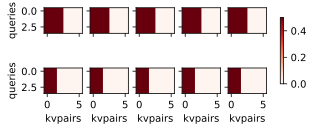

In [86]:
d2l.show_heatmaps(att_weights, xlabel='kvpairs', ylabel='queries',
                 figsize=(5,2), )

### 2. (wait)假设有一个完成训练的基于多头注意力的模型，现在希望修剪最不重要的注意力头以提高预测速度。
如何设计实验来衡量注意力头的重要性呢